# Report figures

Regenerates and **displays** every figure used in the first-year report in one
consistent style.

* **Sans-serif (Helvetica)** for all plot text — deliberately different from the
  Computer Modern serif body.
* One discrete, size-ordered palette for the six GMM clusters (largest water mass
  = calm blue, smallest = warm accent); viridis for every density/depth field.

Each figure is shown inline. To also write one to disk, add `savepath='...png'`
to its call.


In [1]:
# BLAS single-threaded per process (only matters if the BIC sweep is recomputed).
import os
for _v in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
           'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS']:
    os.environ[_v] = '1'

## Figure library (sans-serif)
The shared look and the plotting functions.

In [2]:
"""Cohesive figure library for the Water Mass Classification report.

A single visual language for every figure:
  * viridis family throughout (matches the untouched probability / variance panels)
  * discrete viridis_r for the 6 GMM clusters
  * one sequential map (viridis) for every density / depth heatmap
  * one accent colour for single-series data, one warm accent for highlights
  * identical polar-map furniture (land, coastline, colourbar) everywhere
"""
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.basemap import Basemap

_FS = 1.0  # per-figure font scale (set by the export driver)


def fs(x):
    return x * _FS

# ----------------------------------------------------------------------------
# Palette
# ----------------------------------------------------------------------------
CLUSTER_CMAP = plt.cm.viridis_r          # (kept for reference)
SEQ_CMAP     = 'viridis'                  # sequential density / depth

# Qualitative palette for the discrete GMM clusters. Used for the ensemble-mean
# cluster plots so cluster identity reads categorically rather than as a
# sequential ramp.
QUAL_CMAP = 'gist_rainbow'
CLUSTER_COLOR_SHIFT = 1   # rotate the colour->cluster assignment by this many
ACCENT       = '#31688e'                  # single-series data (viridis blue-teal)
ACCENT_SOFT  = '#8fb8c8'                  # light fill
WARM         = '#e4572e'                  # highlights / threshold markers
INK          = '#22303a'                  # text / dark ink
LAND         = '#e8e8e8'
COAST        = '#5c5c5c'
BLAT         = 47                          # common bounding latitude for all maps


def cluster_colors(n):
    return CLUSTER_CMAP(np.linspace(0, 1, n))


def qual_colors(n):
    """n discrete cluster colours sampled from QUAL_CMAP. Works for both
    qualitative ListedColormaps (uses their swatches) and continuous maps
    such as gist_rainbow (samples n evenly-spaced points)."""
    from matplotlib.colors import to_rgba
    cmap = plt.get_cmap(QUAL_CMAP)
    if hasattr(cmap, 'colors'):  # qualitative ListedColormap
        base = list(cmap.colors)
        cols = np.array([to_rgba(base[i % len(base)]) for i in range(n)])
    else:                        # continuous map
        cols = cmap(np.linspace(0, 1, n))
    # rotate the colour->cluster assignment (cluster i takes colour i+shift)
    return np.roll(cols, -CLUSTER_COLOR_SHIFT, axis=0)


# Muted, colourblind-friendly palette ordered calm -> warm. Assigned to clusters
# by SIZE (see size_ordered_colors), so the largest water mass gets the calm
# blue and the warm brick-red only ever lands on the smallest cluster.
CLUSTER_PALETTE = ['#1f77b4',  # blue    (largest mass)
                   '#ff7f0e',  # orange  (2nd largest — far from blue)
                   '#d62728',  # red
                   '#9467bd',  # purple
                   '#17becf',  # teal    (small cluster)
                   '#2ca02c']  # green   (smallest mass)


def size_ordered_colors(labels, n):
    """Assign CLUSTER_PALETTE to clusters by descending size: colour[k] is the
    palette entry whose rank equals cluster k's size-rank (0 = biggest)."""
    from matplotlib.colors import to_rgba
    order = list(pd.Series(labels).value_counts().index)  # biggest first
    for k in range(n):
        if k not in order:
            order.append(k)
    cols = np.zeros((n, 4))
    for rank, k in enumerate(order[:n]):
        cols[int(k)] = to_rgba(CLUSTER_PALETTE[rank % len(CLUSTER_PALETTE)])
    return cols


def set_style():
    mpl.rcParams.update({
        'text.usetex': False,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
        'axes.unicode_minus': True,
        'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
        'figure.facecolor': 'white', 'axes.facecolor': 'white',
        'font.size': fs(11), 'axes.titlesize': fs(9.9), 'axes.titleweight': 'normal',
        'axes.labelsize': fs(10.5), 'axes.labelcolor': INK, 'text.color': INK,
        'axes.edgecolor': '#c2c2c2', 'axes.linewidth': 0.9,
        'axes.grid': True, 'grid.color': '#ececec', 'grid.linewidth': 0.8,
        'axes.axisbelow': True, 'axes.titlepad': 8,
        'xtick.color': INK, 'ytick.color': INK,
        'xtick.labelsize': fs(9.5), 'ytick.labelsize': fs(9.5),
        'legend.frameon': False, 'legend.fontsize': fs(9.5),
    })


def _seq_cmap():
    c = plt.get_cmap(SEQ_CMAP).copy()
    c.set_under('white', alpha=1.0)
    return c


def polar_map(ax, boundinglat=BLAT, round_map=True):
    """Consistent polar-stereographic basemap furniture on an existing axis.
    round_map=False gives a rectangular frame (so the view can be cropped to a
    sub-region with ax.set_xlim / set_ylim)."""
    m = Basemap(projection='npstere', boundinglat=boundinglat, lon_0=0,
                resolution='l', ax=ax, round=round_map)
    mb = m.drawmapboundary(fill_color='white', linewidth=0.8, color='#c2c2c2')
    mb.set_zorder(-1)  # keep the white background behind the land fill
    m.fillcontinents(color=LAND, lake_color=LAND, zorder=0)
    m.drawcoastlines(linewidth=0.4, color=COAST, zorder=4)
    m.drawparallels(np.arange(50, 91, 10), linewidth=0.25, color='#cfcfcf')
    m.drawmeridians(np.arange(-180, 181, 30), linewidth=0.25, color='#cfcfcf')
    return m


def global_xy_bins(lon, lat, nx=100, ny=100, boundinglat=BLAT):
    """Fixed projected bin edges from the full dataset -> comparable panels."""
    m = Basemap(projection='npstere', boundinglat=boundinglat, lon_0=0, resolution='l')
    x, y = m(np.asarray(lon), np.asarray(lat))
    xb = np.linspace(x.min(), x.max(), nx + 1)
    yb = np.linspace(y.min(), y.max(), ny + 1)
    return xb, yb


def _titlecase(ax, t):
    ax.set_title(t, color=INK)


# ----------------------------------------------------------------------------
# FIGURE 3 — Profile distribution over decades (scatter)
# ----------------------------------------------------------------------------
def fig_profile_decades(df, decades, savepath=None):
    set_style()
    fig, axes = plt.subplots(1, 4, figsize=(15, 4.6))
    for ax, (y0, y1) in zip(axes, decades):
        sub = df[(df['year'] >= y0) & (df['year'] < y1)]
        m = polar_map(ax)
        x, y = m(sub['Longitude_[deg_E]'].values, sub['Latitude_[deg_N]'].values)
        m.scatter(x, y, s=0.6, marker='o', color=ACCENT, alpha=0.35,
                  edgecolors='none', zorder=3, rasterized=True)
        ax.set_title(f'{y0}–{y1}', color=INK, fontsize=fs(9.9))
    fig.suptitle('Profile distribution over decades', fontsize=fs(11),
                 color=INK, y=1.0)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
    return fig


# ----------------------------------------------------------------------------
# FIGURE 4 — Data density over decades (binned heatmap, shared scale)
# ----------------------------------------------------------------------------
def fig_density_decades(df, decades, xb, yb, vmax=65000, savepath=None):
    from matplotlib.colors import LogNorm
    set_style()
    cmap = _seq_cmap()
    m0 = Basemap(projection='npstere', boundinglat=BLAT, lon_0=0, resolution='l')
    fig = plt.figure(figsize=(15, 5.0))
    # Four equal map axes in one row; margins chosen so the map band is as tall
    # as it is wide -> the circles match the size of the Figure 3 panels.
    gs = fig.add_gridspec(1, 4, wspace=0.04, left=0.02, right=0.98,
                          top=0.82, bottom=0.16)
    X, Y = np.meshgrid(xb, yb)
    # Log colour scale: reveals the full spread from sparse (1) to dense bins,
    # instead of collapsing almost everything to the dark end of a linear ramp.
    norm = LogNorm(vmin=1, vmax=vmax)
    pcm = None
    for i, (y0, y1) in enumerate(decades):
        ax = fig.add_subplot(gs[0, i])
        sub = df[(df['year'] >= y0) & (df['year'] <= y1)]
        xs, ys = m0(sub['Longitude_[deg_E]'].values, sub['Latitude_[deg_N]'].values)
        H, _, _ = np.histogram2d(xs, ys, bins=[xb, yb])
        m = polar_map(ax)
        pcm = m.pcolormesh(X, Y, H.T, cmap=cmap, norm=norm, zorder=2)
        ax.set_title(f'{y0}–{y1}', color=INK, fontsize=fs(9.9), pad=4)
    # Dedicated colourbar axis (does not resize the maps)
    cax = fig.add_axes([0.30, 0.075, 0.40, 0.03])
    cbar = fig.colorbar(pcm, cax=cax, orientation='horizontal', extend='max')
    cbar.set_label('Points per bin  (log scale)', color=INK)
    fig.suptitle('Data density over decades  (100×100 polar-stereographic bins)',
                 fontsize=fs(11), color=INK, y=0.95)
    if savepath:
        fig.savefig(savepath)
    return fig


# ----------------------------------------------------------------------------
# FIGURE 5 — Bin-capacity curves (matplotlib replacement for the plotly version)
# ----------------------------------------------------------------------------
def _bin_capacity(df, nx=100, ny=100):
    """Sorted occupied-bin counts, replicating profileNo_vs_xy_bins:
    project with boundinglat = this subset's own min latitude and bin over its
    own projected extent."""
    lat_min = df['Latitude_[deg_N]'].min()
    m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution='l')
    x, y = m(df['Longitude_[deg_E]'].values, df['Latitude_[deg_N]'].values)
    xb = np.linspace(x.min(), x.max(), nx + 1)
    yb = np.linspace(y.min(), y.max(), ny + 1)
    H, _, _ = np.histogram2d(x, y, bins=[xb, yb])
    g = np.sort(H[H > 0].astype(int))
    return g


def _threshold_point(g, q):
    if len(g) < 2:
        return None
    diff = np.diff(g)
    thr = np.quantile(diff, q)
    for i in range(1, len(g)):
        if g[i] - g[i - 1] > thr:
            return i - 1
    return None


def fig_bin_capacity(panels, ncols=2, savepath=None):
    """panels: list of (title, df, quantile_or_None). None-df panels leave a gap."""
    set_style()
    n = len(panels)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.5 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.axis('off')
    for ax, (title, df, q) in zip(axes, panels):
        if df is None:
            ax.axis('off'); ax.set_title(title, color=INK, fontsize=fs(9.9)); continue
        g = _bin_capacity(df)
        x = np.arange(len(g))
        ax.plot(x, g, color=ACCENT, lw=1.8)
        ax.fill_between(x, g, color=ACCENT_SOFT, alpha=0.35)
        if q is not None:
            tp = _threshold_point(g, q)
            if tp is not None:
                ax.scatter([tp], [g[tp]], color=WARM, s=42, zorder=5,
                           edgecolors='white', linewidths=0.8)
                ax.annotate(f'threshold ≈ {g[tp]:,}',
                            xy=(tp, g[tp]), xytext=(0.04, 0.86),
                            textcoords='axes fraction', color=WARM, fontsize=fs(9.5),
                            arrowprops=dict(arrowstyle='-', color=WARM, lw=0.8))
        ax.set_xlabel('Bin no. (sorted)')
        ax.set_ylabel('Profiles per bin')
        ax.set_title(title, color=INK, fontsize=fs(9.9))
        ax.margins(x=0.01)
    fig.suptitle('Bin-capacity distributions (Zheng threshold method)',
                 fontsize=fs(11), color=INK, y=1.0)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
    return fig


# ----------------------------------------------------------------------------
# FIGURE 6 — Depth / Year / Month distributions (one figure per dataset)
# ----------------------------------------------------------------------------
def fig_distribution(df, row_label, savepath=None):
    """One row of Depth / Year / Month histograms for a single dataset."""
    set_style()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
    specs = [('Depth_[m]', 'Depth (m)', 30),
             ('year', 'Year', 30),
             ('month', 'Month', 12)]
    for ax, (col, xlabel, bins) in zip(axes, specs):
        ax.hist(df[col], bins=bins, color=ACCENT, alpha=0.85,
                edgecolor='white', linewidth=0.5)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Frequency')
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax.set_title(xlabel.split(' (')[0], color=INK)
    fig.suptitle(f'Feature distributions — {row_label}',
                 fontsize=fs(11), color=INK, y=1.0)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
    return fig


def fig_distributions(df_before, df_after, savepath=None):
    set_style()
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    specs = [('Depth_[m]', 'Depth (m)', 30),
             ('year', 'Year', 30),
             ('month', 'Month', 12)]
    rows = [('Before sampling', df_before), ('After sampling', df_after)]
    for r, (rlabel, d) in enumerate(rows):
        for c, (col, xlabel, bins) in enumerate(specs):
            ax = axes[r, c]
            ax.hist(d[col], bins=bins, color=ACCENT, alpha=0.85,
                    edgecolor='white', linewidth=0.5)
            ax.set_xlabel(xlabel)
            if c == 0:
                ax.set_ylabel(f'{rlabel}\nFrequency', fontweight='semibold')
            else:
                ax.set_ylabel('Frequency')
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
            if r == 0:
                ax.set_title(xlabel.split(' (')[0], color=INK)
    fig.suptitle('Feature distributions before and after sampling',
                 fontsize=fs(11), color=INK, y=0.99)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
    return fig


# ----------------------------------------------------------------------------
# FIGURE 7 — Density before / after + GEBCO max depth
# ----------------------------------------------------------------------------
def fig_density_bathymetry(df_before, df_after, df_topo, xb, yb,
                           vmax_density=None, savepath=None):
    set_style()
    cmap = _seq_cmap()
    m0 = Basemap(projection='npstere', boundinglat=BLAT, lon_0=0, resolution='l')

    def counts(d):
        xs, ys = m0(d['Longitude_[deg_E]'].values, d['Latitude_[deg_N]'].values)
        H, _, _ = np.histogram2d(xs, ys, bins=[xb, yb])
        return H

    Hb, Ha = counts(df_before), counts(df_after)
    if vmax_density is None:
        vmax_density = np.percentile(Hb[Hb > 0], 99)

    # GEBCO: max depth per bin (vectorised)
    xt, yt = m0(df_topo['Longitude_[deg_E]'].values, df_topo['Latitude_[deg_N]'].values)
    xi = np.clip(np.digitize(xt, xb) - 1, 0, len(xb) - 2)
    yi = np.clip(np.digitize(yt, yb) - 1, 0, len(yb) - 2)
    Ht = np.zeros((len(xb) - 1, len(yb) - 1))
    np.maximum.at(Ht, (xi, yi), df_topo['Depth_[m]'].values)

    X, Y = np.meshgrid(xb, yb)
    vmax_depth = np.percentile(Ht[Ht > 0], 99)

    fig = plt.figure(figsize=(15, 5.6))
    # top row: 3 equal maps; bottom row: colourbars
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.045], wspace=0.04, hspace=0.05,
                          left=0.02, right=0.98, top=0.82, bottom=0.1)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2])

    # Two density panels share one scale...
    # Mask empty bins so the grey land shows through (instead of white cells)
    pcm_d = None
    for ax, H, t in [(ax0, Hb, 'Before sampling'), (ax1, Ha, 'After sampling')]:
        m = polar_map(ax)
        pcm_d = m.pcolormesh(X, Y, np.ma.masked_less(H.T, 1), cmap=cmap,
                             vmin=1, vmax=vmax_density, zorder=2)
        ax.set_title(t, color=INK)
    # ...and one shared colourbar spanning both
    cax_d = fig.add_subplot(gs[1, 0:2])
    cbar_d = fig.colorbar(pcm_d, cax=cax_d, orientation='horizontal', extend='max')
    cbar_d.set_label('Points per bin', color=INK, fontsize=fs(9.5))

    # Bathymetry panel: its own (different quantity) colourbar
    m2 = polar_map(ax2)
    pcm_z = m2.pcolormesh(X, Y, np.ma.masked_less(Ht.T, 1), cmap=cmap,
                          vmin=1, vmax=vmax_depth, zorder=2)
    ax2.set_title('GEBCO max depth per bin', color=INK)
    cax_z = fig.add_subplot(gs[1, 2])
    cbar_z = fig.colorbar(pcm_z, cax=cax_z, orientation='horizontal', extend='max')
    cbar_z.set_label('Max depth (m)', color=INK, fontsize=fs(9.5))

    fig.suptitle('Sampling effect on data density, with GEBCO bathymetry',
                 fontsize=fs(11), color=INK, y=0.95)
    if savepath:
        fig.savefig(savepath)
    return fig


# ----------------------------------------------------------------------------
# FIGURE 2 — PhD research-plan Gantt
# ----------------------------------------------------------------------------
def fig_gantt(savepath=None):
    from matplotlib.patches import Patch
    set_style()
    chapters = ["Ch.1  Arctic Water Masses", "Ch.2  Global Water Masses",
                "Ch.3  Budgets (Heat/Carbon/Nutrients)",
                "Ch.4  Trends, Variability & MOC", "Thesis"]
    colors = cluster_colors(5)[::-1]  # viridis (not reversed) across chapters
    tasks = [
        ("ML water mass classification method", 0, 0.0, 0.85),
        ("Publish method (paper)", 0, 0.75, 0.58),
        ("Apply method to global data", 1, 1.0, 0.7),
        ("Apply method to modelled data & make alterations (extra tracers)", 1, 1.5, 0.5),
        ("Heat, carbon & nutrient budgets per water mass", 2, 2.0, 1.0),
        ("Trends: natural vs anthropogenic attribution", 3, 2.66, 0.64),
        ("Climate variability & future trends", 3, 3.3, 0.35),
        ("Writing Up Thesis", 4, 3.5, 0.5),
    ]
    fig, ax = plt.subplots(figsize=(12, 5.5))
    ax.grid(False)
    yticks, ylabels = [], []
    for i, (label, cidx, start, dur) in enumerate(tasks):
        y = len(tasks) - i
        ax.barh(y, dur, left=start, height=0.6, color=colors[cidx],
                edgecolor='white', zorder=3)
        yticks.append(y); ylabels.append(label)
    ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=fs(9.9))
    ax.set_xlim(0, 4)
    ax.set_xticks([0.5, 1.5, 2.5, 3.5])
    ax.set_xticklabels(["Year 1", "Year 2", "Year 3", "Year 4"],
                       fontsize=fs(9.9))
    ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", length=0)
    for x in [1, 2, 3]:
        ax.axvline(x, color="0.85", linewidth=1, zorder=1)
    # light grey mid-year guides, behind the coloured blocks
    for x in [0.5, 1.5, 2.5, 3.5]:
        ax.axvline(x, color="0.9", linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    legend_handles = [Patch(color=colors[i], label=chapters[i]) for i in range(len(chapters))]
    ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.05),
              fontsize=fs(9), ncol=3, frameon=False)
    ax.set_title("PhD Research Plan", fontsize=fs(11), pad=14, color=INK)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
    return fig


# ----------------------------------------------------------------------------
# FIGURE 8 — BIC ensemble sweep
# ----------------------------------------------------------------------------
def fig_bic(all_scores, n_range, chosen_k=6, savepath=None):
    set_style()
    fig, ax = plt.subplots(figsize=(9, 5.2))
    S = np.array([all_scores[i] for i in sorted(all_scores)])  # (members, n)
    for row in S:
        ax.plot(list(n_range), row, color=ACCENT, alpha=0.14, lw=1.0, zorder=2)
    mean = S.mean(axis=0)
    ax.plot(list(n_range), mean, color=WARM, lw=2.6, zorder=4,
            marker='o', ms=6, label='Ensemble mean')
    ax.axvline(chosen_k, color=INK, ls='--', lw=1.1, zorder=3, alpha=0.6)
    ax.scatter([chosen_k], [mean[list(n_range).index(chosen_k)]],
               s=120, facecolors='none', edgecolors=INK, linewidths=1.6, zorder=5)
    ax.annotate(f'chosen K = {chosen_k}', xy=(chosen_k, mean[list(n_range).index(chosen_k)]),
                xytext=(0.62, 0.7), textcoords='axes fraction', color=INK, fontsize=fs(10.5),
                arrowprops=dict(arrowstyle='->', color=INK, lw=1.0))
    ax.set_xlabel('Number of components  K')
    ax.set_ylabel('BIC score')
    ax.set_title('BIC across the 100-member GMM ensemble', color=INK, fontsize=fs(11))
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], color=WARM, lw=2.6, marker='o', ms=6, label='Ensemble mean'),
        Line2D([0], [0], color=ACCENT, lw=1.4, alpha=0.6, label='Ensemble members'),
    ]
    ax.legend(handles=handles, loc='upper right')
    ax.margins(x=0.02)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
    return fig


# ----------------------------------------------------------------------------
# FIGURE 9a — Ensemble-mean clusters, geographic (polar) top view
# ----------------------------------------------------------------------------
def fig_clusters_geo(df, n_clusters, label='mean_cluster', sample=120000,
                     seed=22, savepath=None, legend_below=False,
                     square_crop=False, title='GMM ensemble-mean clusters — geographic view'):
    set_style()
    from matplotlib.lines import Line2D
    d = df.sample(n=min(sample, len(df)), random_state=seed)
    cols = size_ordered_colors(df[label].values, n_clusters)
    fig, ax = plt.subplots(figsize=(8.5, 8.5))
    ax.grid(False)
    m = polar_map(ax, round_map=False)   # rectangular frame so we can crop
    x, y = m(d['Longitude_[deg_E]'].values, d['Latitude_[deg_N]'].values)
    for k in range(n_clusters):
        mask = d[label].values == k
        m.scatter(x[mask], y[mask], s=3.0, color=cols[k], alpha=0.55,
                  edgecolors='none', zorder=3, rasterized=True)
    # Zoom to the footprint of the points (with a small margin)
    x0, x1, y0, y1 = x.min(), x.max(), y.min(), y.max()
    if square_crop:
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        half = max(x1 - x0, y1 - y0) / 2 * 1.06
        ax.set_xlim(cx - half, cx + half)
        ax.set_ylim(cy - half, cy + half)
    else:
        padx, pady = 0.05 * (x1 - x0), 0.05 * (y1 - y0)
        ax.set_xlim(x0 - padx, x1 + padx)
        ax.set_ylim(y0 - pady, y1 + pady)
    handles = [Line2D([0], [0], marker='o', ls='none', ms=8, mec='none',
                      color=cols[k], label=f'Cluster {k}') for k in range(n_clusters)]
    if legend_below:
        ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.02),
                  ncol=min(3, n_clusters), title='GMM cluster', title_fontsize=fs(10))
    else:
        ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
                  title='GMM cluster', title_fontsize=fs(10))
    ax.set_title(title, color=INK, fontsize=fs(11))
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath)
    return fig


# ----------------------------------------------------------------------------
# FIGURE 9b — Ensemble-mean clusters, cross-section through the North Pole
# ----------------------------------------------------------------------------
def _great_circle_km(lat_ref, lon_ref, lats, lons):
    from pyproj import Geod
    geod = Geod(ellps='WGS84')
    _, _, d = geod.inv(np.full(len(lats), lon_ref), np.full(len(lats), lat_ref), lons, lats)
    return d / 1000.0


def fig_cross_section(df, n_clusters, label='mean_cluster', tol=0.5,
                      start_lat=70.0, start_lon=-140.0, lon_value=0.0,
                      max_depth=1000, savepath=None):
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    set_style()
    prim = df[(df['Longitude_[deg_E]'] >= start_lon - tol) &
              (df['Longitude_[deg_E]'] <= start_lon + tol)].copy()
    anti = df[(df['Longitude_[deg_E]'] >= lon_value - tol) &
              (df['Longitude_[deg_E]'] <= lon_value + tol)].copy()
    sl = pd.concat([prim, anti], ignore_index=True)
    sl['dist_km'] = _great_circle_km(start_lat, start_lon,
                                     sl['Latitude_[deg_N]'].values,
                                     sl['Longitude_[deg_E]'].values)
    cmap = ListedColormap(size_ordered_colors(df[label].values, n_clusters))
    norm = BoundaryNorm(np.arange(-0.5, n_clusters + 0.5, 1), cmap.N)

    fig = plt.figure(figsize=(16, 5.2))
    # columns: cross-section | colourbar | spacer (holds cbar labels) | inset map
    gs = fig.add_gridspec(1, 4, width_ratios=[3, 0.11, 0.34, 1.7], wspace=0.06)
    ax = fig.add_subplot(gs[0]); ax.grid(False)
    cax = fig.add_subplot(gs[1])
    ax_map = fig.add_subplot(gs[3], projection=ccrs.NorthPolarStereo())
    ax.scatter(sl['dist_km'], sl['Depth_[m]'], c=sl[label], cmap=cmap,
               norm=norm, s=7, alpha=0.55, edgecolors='none', rasterized=True)
    ax.set_ylim(max_depth, 0)
    ax.set_xlabel(f'Distance (km) from {start_lat:.0f}°N, {abs(start_lon):.0f}°W')
    ax.set_ylabel('Depth (m)')
    ax.set_title('GMM ensemble-mean clusters — cross-section through the North Pole',
                 color=INK, fontsize=fs(11))

    # Solid (opaque) discrete colourbar, colours identical to the plotted clusters
    from matplotlib.cm import ScalarMappable
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.solids.set_alpha(1.0)
    cbar.set_ticks(range(n_clusters))
    cbar.set_ticklabels([f'Cluster {i}' for i in range(n_clusters)])
    cbar.ax.invert_yaxis()  # Cluster 0 at top, matching the Fig 9a legend order
    cbar.outline.set_linewidth(0.6)

    ax_map.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor=LAND, zorder=1)
    ax_map.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor=COAST, zorder=2)
    ax_map.plot([start_lon, lon_value, lon_value], [start_lat, 90.0, start_lat],
                color=WARM, linewidth=1.8, transform=ccrs.Geodetic(), zorder=3)
    ax_map.scatter([start_lon, lon_value], [start_lat, start_lat], color=WARM,
                   s=18, transform=ccrs.PlateCarree(), zorder=4)
    ax_map.set_title('Section location', fontsize=fs(10), color=INK)
    if savepath:
        fig.savefig(savepath)
    return fig


## Data
Raw compilation, the Method-34 sampled set, GEBCO bathymetry, and the saved GMM
ensemble result. Heaviest cell (~11 M rows).

In [3]:
import numpy as np
import pandas as pd
from funcs import method34, sample_cap_bins_xy

RAW  = '/Users/franciscagomes/PhD/WM_class/WMA_fractions_v2.csv'
GEB  = '/Users/franciscagomes/PhD/WM_class/gebco_2025_sub_ice_roi.tif'
ENS  = '/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Paper1/Cluster_n_sensitivity/WMA_fractions_v2_with_PV_GMM_ensemble.csv'

_use = ['Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]', 'Datetime_[UTC]']
df_raw = pd.read_csv(RAW, skiprows=1, usecols=_use)
_dt = pd.to_datetime(df_raw['Datetime_[UTC]'])
df_raw['year'] = _dt.dt.year; df_raw['month'] = _dt.dt.month
df_raw = df_raw[df_raw['year'] >= 1980].reset_index(drop=True)

df_sampled = method34(df=df_raw[['Depth_[m]', 'Latitude_[deg_N]',
                                 'Longitude_[deg_E]', 'year', 'month']].copy())
xb, yb = global_xy_bins(df_raw['Longitude_[deg_E]'], df_raw['Latitude_[deg_N]'])
decades = [(1980, 1990), (1990, 2000), (2000, 2010), (2010, 2023)]
print('raw', df_raw.shape, 'sampled', df_sampled.shape)

raw (11402917, 6) sampled (5567020, 6)


In [4]:
# GEBCO bathymetry (decimated on read)
import rasterio
from rasterio.enums import Resampling
from pyproj import Transformer
with rasterio.open(GEB) as src:
    _d = 6; _oh, _ow = src.height // _d, src.width // _d
    _data = src.read(1, out_shape=(_oh, _ow), resampling=Resampling.average)
    _tr = src.transform * src.transform.scale(src.width / _ow, src.height / _oh)
    _crs = src.crs
_r, _c = np.meshgrid(np.arange(_oh), np.arange(_ow), indexing='ij')
_xs, _ys = rasterio.transform.xy(_tr, _r.flatten(), _c.flatten())
_lon, _lat = Transformer.from_crs(_crs, 'EPSG:4326', always_xy=True).transform(_xs, _ys)
df_topo = pd.DataFrame({'Longitude_[deg_E]': _lon, 'Latitude_[deg_N]': _lat,
                        'Depth_[m]': -_data.flatten()})
df_topo = df_topo[(df_topo['Depth_[m]'] > 0) & (df_topo['Latitude_[deg_N]'] >= BLAT)]

ens_cols = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'PV',
            'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]', 'mean_cluster']
df_ens = pd.read_csv(ENS, usecols=ens_cols)
print('topo', df_topo.shape, 'ens', df_ens.shape)

topo (13108125, 3) ens (5098705, 7)


---
## Figure 2 — PhD research plan

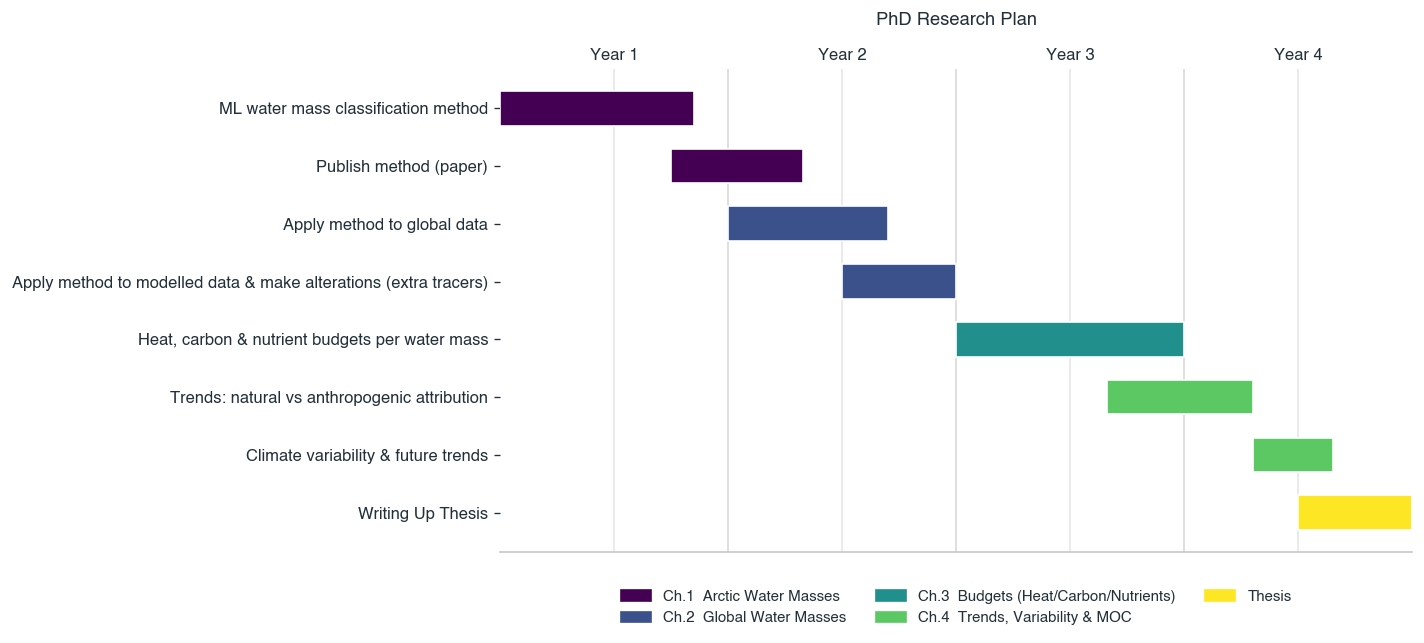

In [5]:
_ = fig_gantt()

---
## Figure 3 — Profile distribution over decades

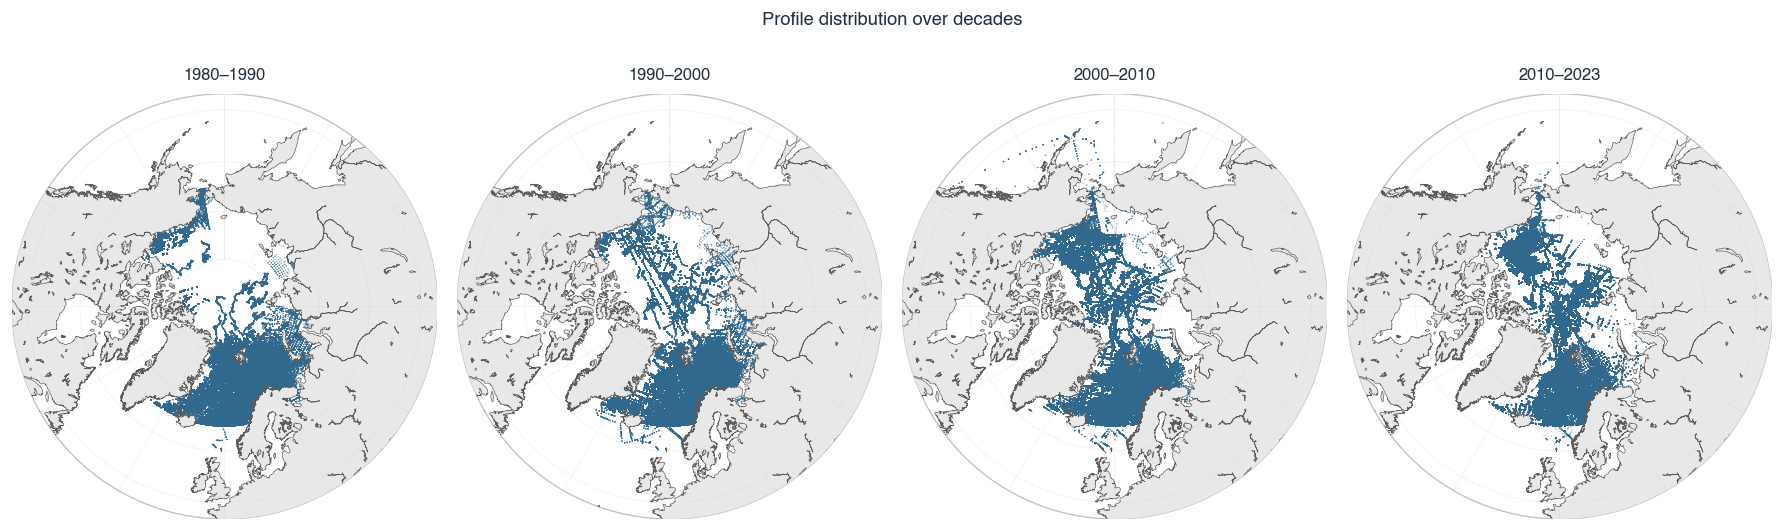

In [6]:
_ = fig_profile_decades(df_raw, decades)

---
## Figure 4 — Data density over decades

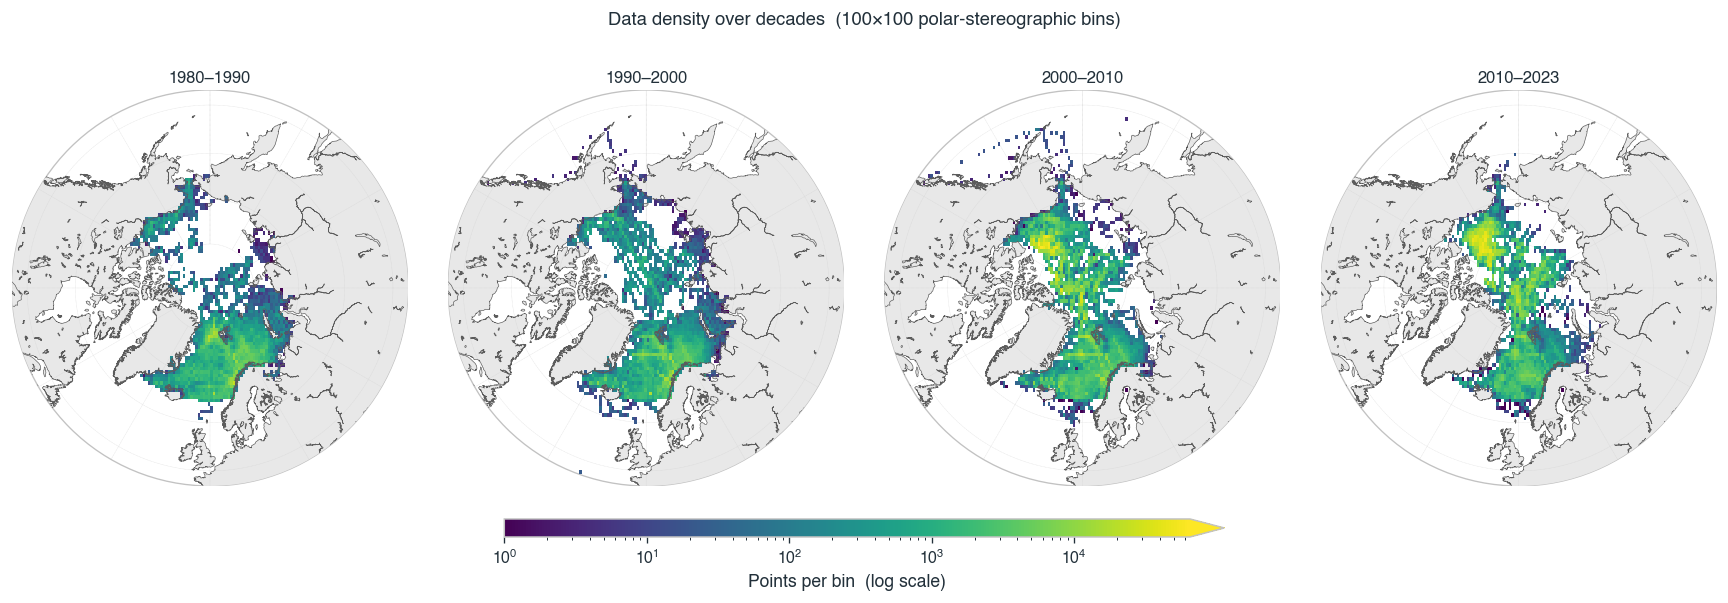

In [7]:
_ = fig_density_decades(df_raw, decades, xb, yb, vmax=65000)

---
## Figure 5 — Bin-capacity distributions

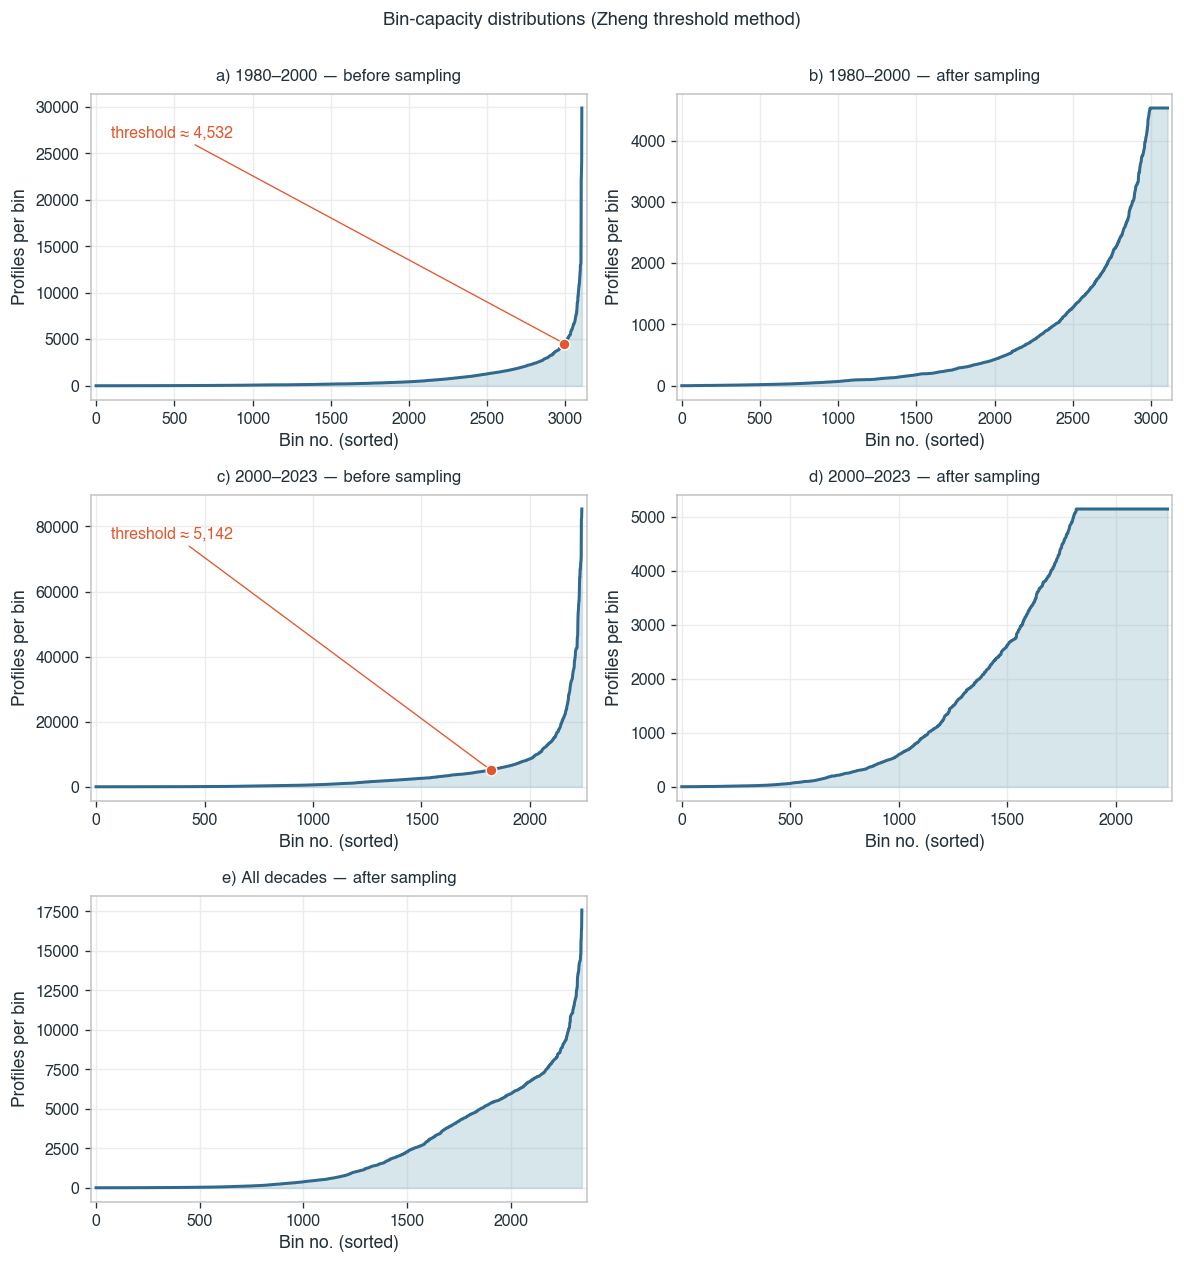

In [8]:
df_80_00 = df_raw[(df_raw['year'] >= 1980) & (df_raw['year'] < 2000)]
df_00_23 = df_raw[(df_raw['year'] >= 2000) & (df_raw['year'] < 2023)]
_g0 = _bin_capacity(df_80_00); thr0 = int(_g0[_threshold_point(_g0, 0.99)])
_g1 = _bin_capacity(df_00_23); thr1 = int(_g1[_threshold_point(_g1, 0.935)])
np.random.seed(22)
df_80_00_s = sample_cap_bins_xy(df_80_00, thresh=thr0, n_x_bins=100, n_y_bins=100)
df_00_23_s = sample_cap_bins_xy(df_00_23, thresh=thr1, n_x_bins=100, n_y_bins=100)
panels = [('a) 1980–2000 — before sampling', df_80_00,   0.99),
          ('b) 1980–2000 — after sampling',  df_80_00_s, None),
          ('c) 2000–2023 — before sampling', df_00_23,   0.935),
          ('d) 2000–2023 — after sampling',  df_00_23_s, None),
          ('e) All decades — after sampling', df_sampled, None)]
_ = fig_bin_capacity(panels, ncols=2)

---
## Figure 6 — Feature distributions before / after sampling

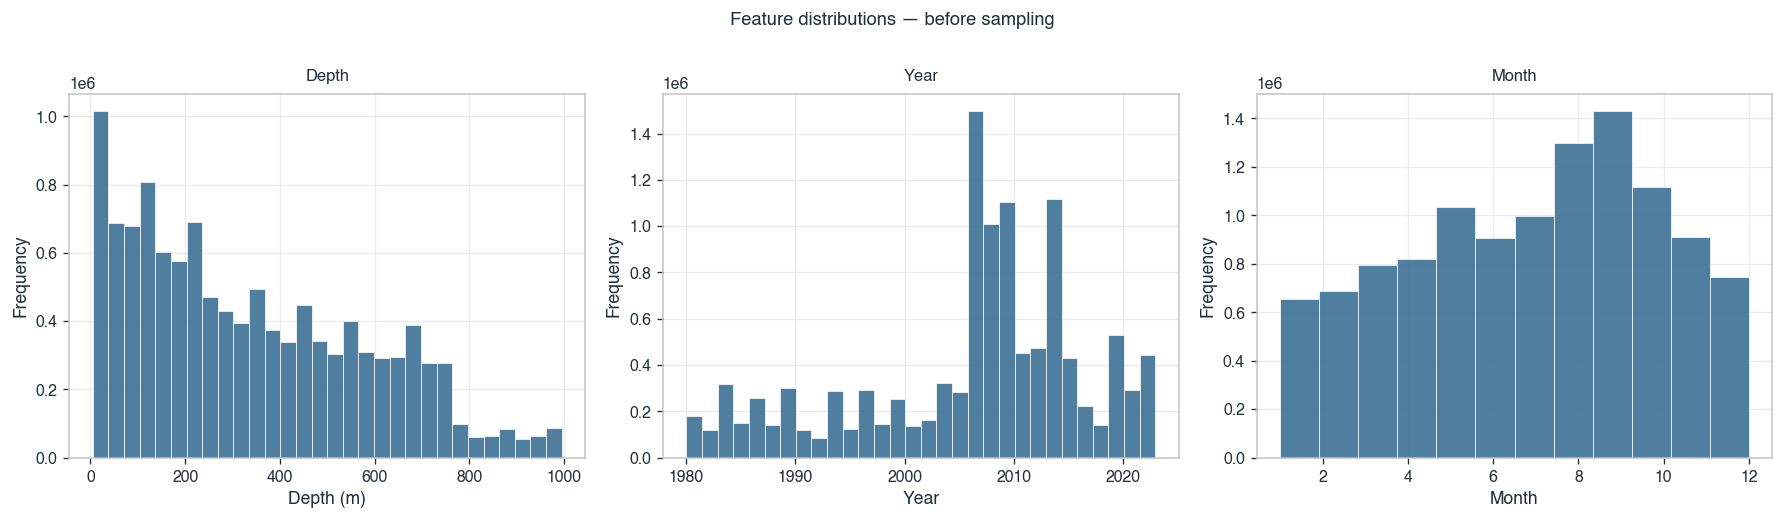

In [9]:
_ = fig_distribution(df_raw, 'before sampling')

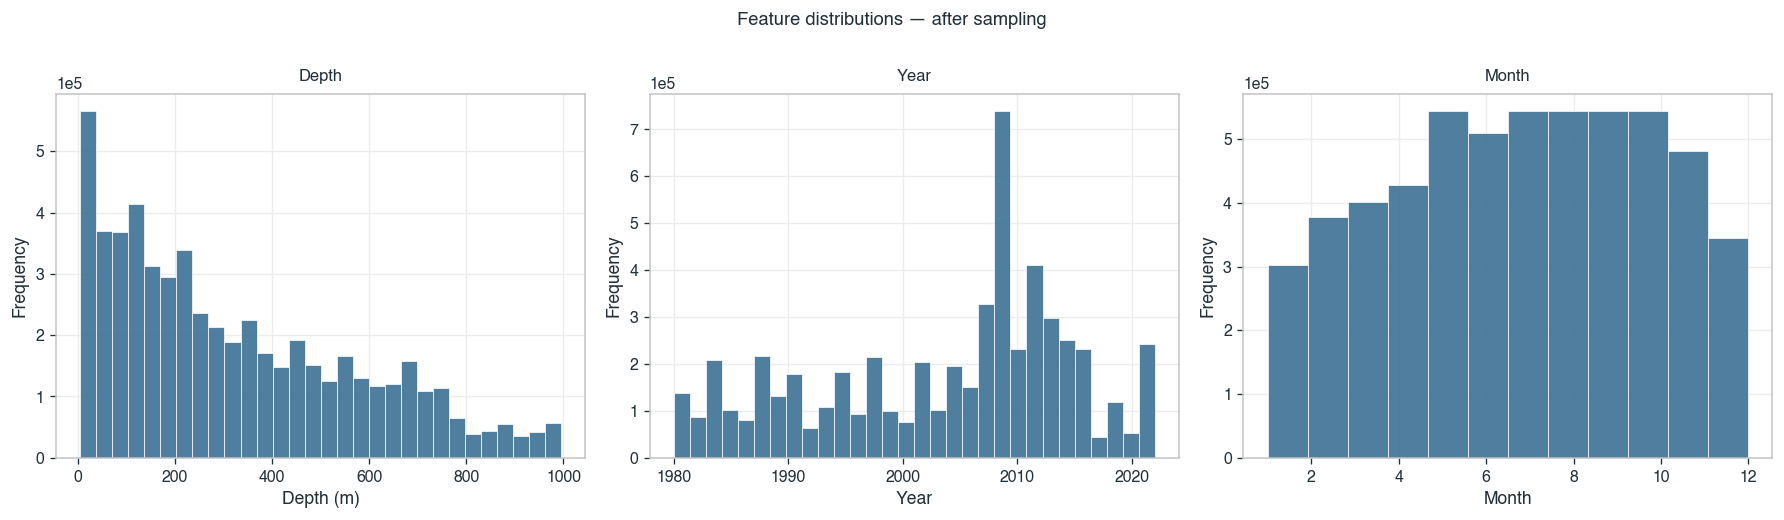

In [10]:
_ = fig_distribution(df_sampled, 'after sampling')

---
## Figure 7 — Density before/after + GEBCO bathymetry

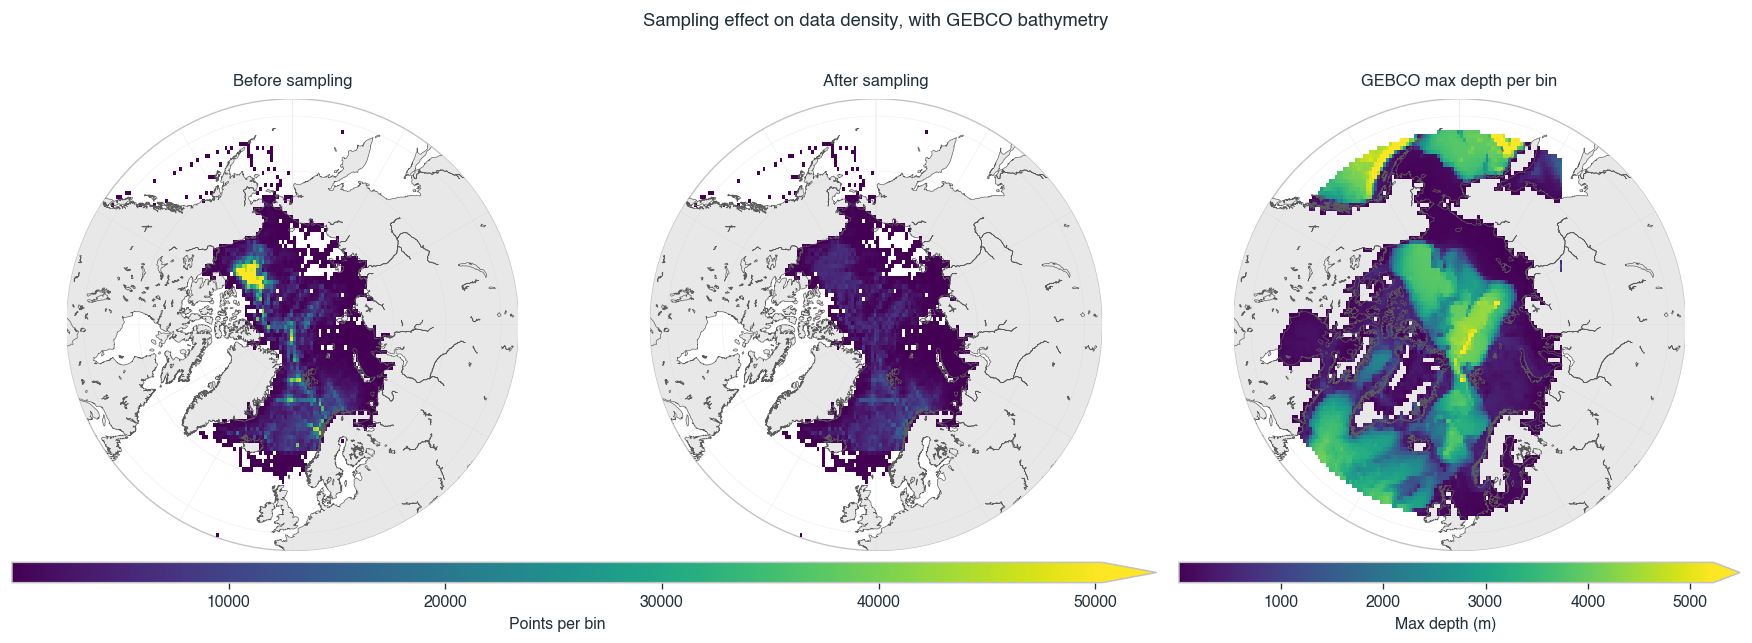

In [11]:
_ = fig_density_bathymetry(df_raw, df_sampled, df_topo, xb, yb)

---
## Figure 8 — BIC across the ensemble

Loads the saved 100-member scores if present (`Report/bic_scores.npy`); otherwise
re-fits the sweep (100 seeds × K=1…7, ~25 min).

loaded saved BIC scores (100, 7)


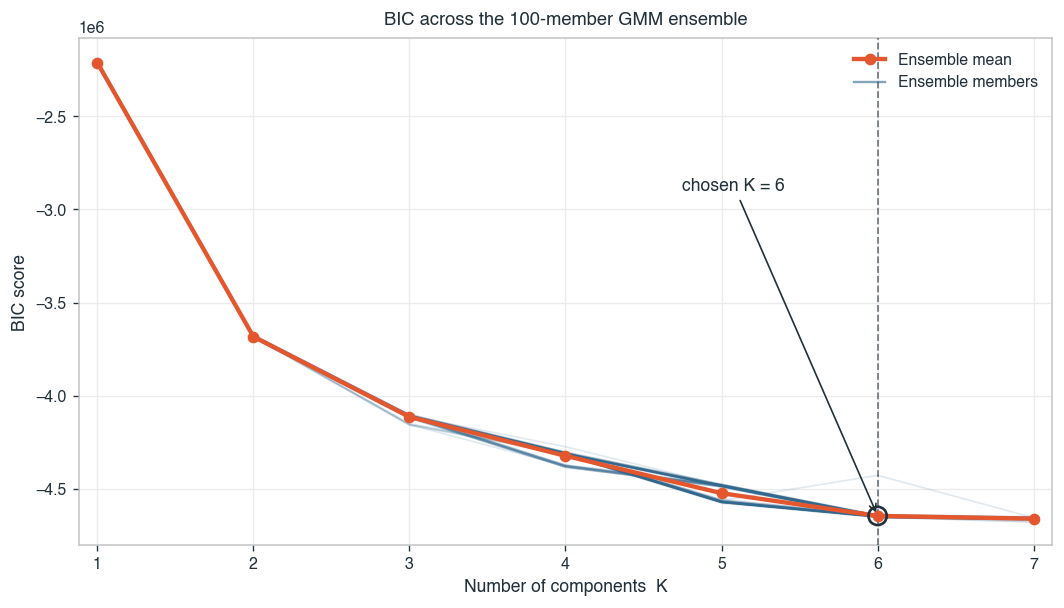

In [12]:
if os.path.exists('bic_scores.npy'):
    _S = np.load('bic_scores.npy')
    all_scores = {i: list(_S[i]) for i in range(len(_S))}
    print('loaded saved BIC scores', _S.shape)
else:
    import random, tempfile
    from sklearn.mixture import GaussianMixture
    from joblib import Parallel, delayed
    _feats = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'PV']
    random.seed(22); seeds = random.sample(range(1, 10000), 100); n_range = range(1, 8)
    _X = df_ens[_feats].to_numpy()
    _tmp = tempfile.mktemp(suffix='.npy'); np.save(_tmp, _X)
    _Xmm = np.load(_tmp, mmap_mode='r'); del _X
    def _fit(seed):
        rng = np.random.default_rng(seed)
        idx = np.sort(rng.choice(len(_Xmm), size=min(500_000, len(_Xmm)), replace=False))
        Xs = np.asarray(_Xmm[idx])
        return [GaussianMixture(n_components=n, covariance_type='full', random_state=seed,
                                max_iter=10_000, n_init=1).fit(Xs).bic(Xs) for n in n_range]
    _res = Parallel(n_jobs=-1, backend='loky')(delayed(_fit)(s) for s in seeds)
    os.remove(_tmp)
    all_scores = {i: r for i, r in enumerate(_res)}
    np.save('bic_scores.npy', np.array([all_scores[i] for i in sorted(all_scores)]))

_ = fig_bic(all_scores, range(1, 8), chosen_k=6)

---
## Figure 9a — Ensemble-mean clusters, geographic view

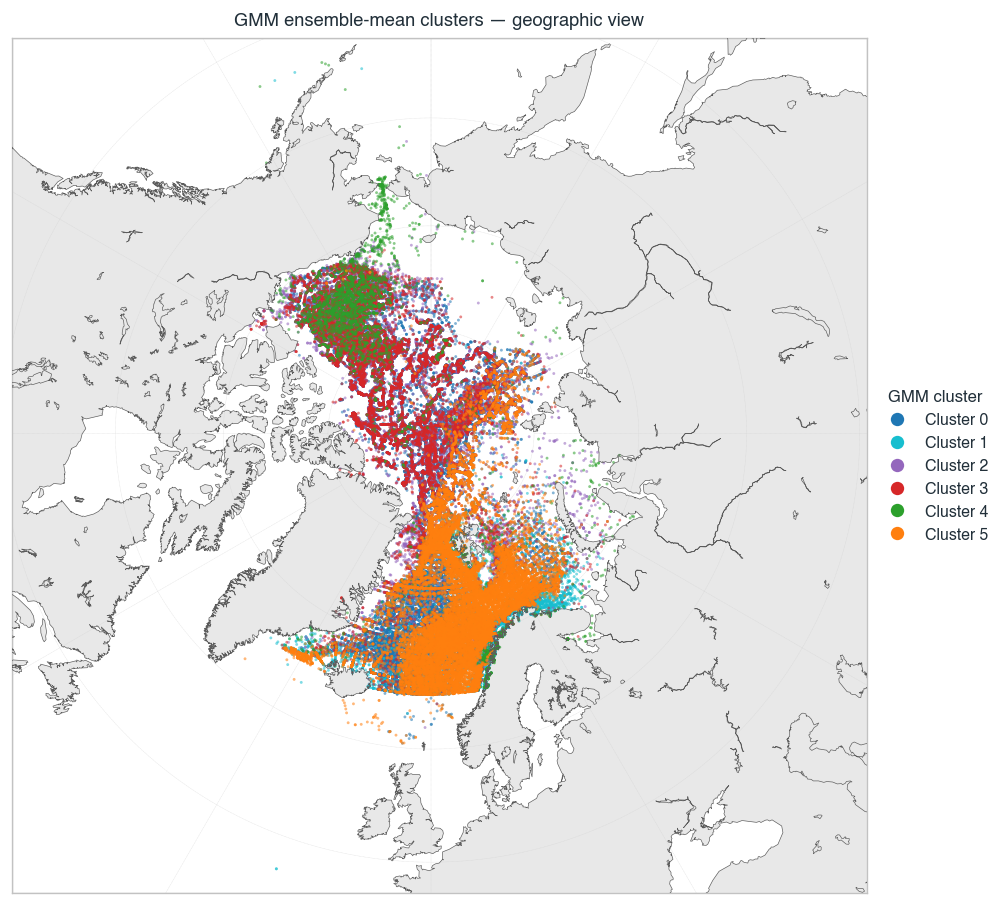

In [13]:
_ = fig_clusters_geo(df_ens, 6, label='mean_cluster', square_crop=True)

---
## Figure 9b — Ensemble-mean clusters, cross-section through the North Pole

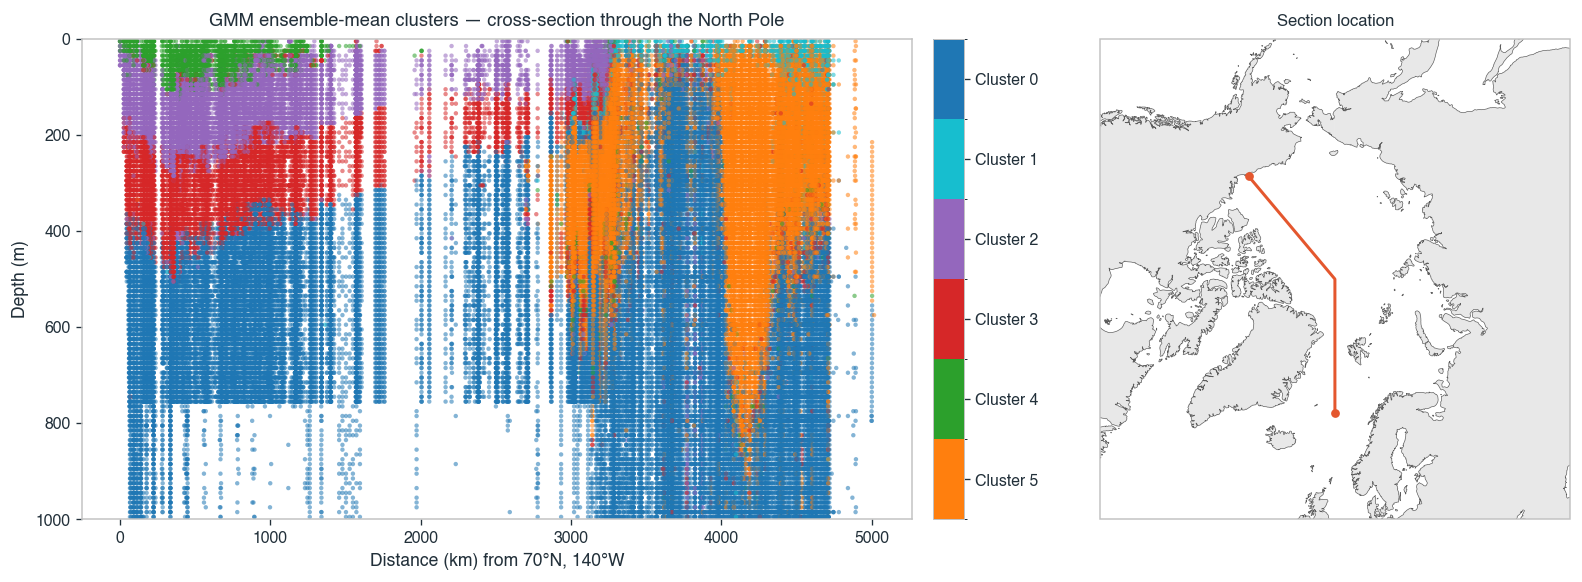

In [14]:
_ = fig_cross_section(df_ens, 6, label='mean_cluster', lon_value=0.0,
                      start_lat=70.0, start_lon=-140.0, max_depth=1000)

---
*Figures 10b/10c (cluster probability and variance) are left unchanged, as
requested. Edit the data paths at the top if the files move.*